In [35]:
%load_ext autoreload
%autoreload 2
import os
import shutil
import hydra
from scipy.spatial.transform import Rotation as R
import pathlib
from pathlib import Path
import wandb
import torch
import tqdm
import dill
import json
import numpy as np
import datetime
import matplotlib.pyplot as plt
from diffusion_policy.workspace.base_workspace import BaseWorkspace
from diffusion_policy.env_runner.robomimic_image_runner_joint_space import RobomimicImageRunnerJointSpace
from diffusion_policy.policy.diffusion_unet_hybrid_image_policy import DiffusionUnetHybridImagePolicy

from hydra import compose, initialize
from omegaconf import OmegaConf

config_path = Path("diffusion_policy/config/train_diffusion_unet_hybrid_workspace.yaml")
DATASET_PATH = "/data/scene-rep/u/iyu/scene-jacobian-discovery/diff-policy/diffusion_policy/data/robomimic/datasets/lift/ph/image_abs.hdf5"
DATASET_PATH_DELTA = "/data/scene-rep/u/iyu/scene-jacobian-discovery/diff-policy/diffusion_policy/data/robomimic/datasets/lift/ph/image.hdf5"
overrides = [
    # "config-name=train_robomimic_image_joint_space_workspace.yaml",
    "task=lift_image_abs_joint_space",
    f"task.env_runner.dataset_path={DATASET_PATH}",
    "task.env_runner.n_train=0",
    "task.env_runner.n_train_vis=0",
    "task.env_runner.n_test=1",
    "task.env_runner.n_test_vis=1",
]

OmegaConf.register_new_resolver("eval", eval, replace=True)
with initialize(version_base=None, config_path=str("../../" / config_path.parent)):
    cfg = compose(config_name=str(config_path.name), overrides=overrides)

OmegaConf.resolve(cfg)

os.environ["CUDA_VISIBLE_DEVICES"] = "5"
os.environ["MUJOCO_GL"] = "egl"
os.environ["DISPLAY"] = ":1"
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

LIFT_IMAGE_ONLY_JS_CKPT = "/data/scene-rep/u/iyu/scene-jacobian-discovery/diff-policy/diffusion_policy/data/outputs/2025.04.30/00.44.03_train_diffusion_unet_hybrid_lift_image_only_joint_space/checkpoints/latest.ckpt"
LIFT_IMAGE_ABS_JS_CKPT = "/data/scene-rep/u/iyu/scene-jacobian-discovery/diff-policy/diffusion_policy/data/outputs/2025.04.28/18.19.50_train_diffusion_unet_hybrid_lift_image_abs_joint_space/checkpoints/latest.ckpt"
LIFT_IMAGE_ONLY_CKPT = "/data/scene-rep/u/iyu/scene-jacobian-discovery/diff-policy/diffusion_policy/data/outputs/2025.04.30/00.45.20_train_diffusion_unet_hybrid_lift_image/checkpoints/latest.ckpt"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using device: cuda


### Load the dataset

In [36]:
import h5py
import mediapy as media

def load_dataset(dataset_path):
    f = h5py.File(dataset_path, "r")
    demos = sorted(list(f["data"].keys()))
    # extract filter key information
    if "mask" in f:
        all_filter_keys = {}
        for fk in f["mask"]:
            fk_demos = sorted([elem.decode("utf-8") for elem in np.array(f["mask/{}".format(fk)])])
            all_filter_keys[fk] = fk_demos

    # put demonstration list in increasing episode order
    inds = np.argsort([int(elem[5:]) for elem in demos])
    demos = [demos[i] for i in inds]
    # extract length of each trajectory in the file
    traj_lengths = []
    action_min = np.inf
    action_max = -np.inf
    joint_pos_min = np.inf
    joint_pos_max = -np.inf
    for ep in demos:
        traj_lengths.append(f["data/{}/actions".format(ep)].shape[0])
        action_min = min(action_min, np.min(f["data/{}/actions".format(ep)][()]))
        action_max = max(action_max, np.max(f["data/{}/actions".format(ep)][()]))
        joint_pos_min = min(joint_pos_min, np.min(f["data/{}/obs/robot0_joint_pos".format(ep)][()]))
        joint_pos_max = max(joint_pos_max, np.max(f["data/{}/obs/robot0_joint_pos".format(ep)][()]))
    traj_lengths = np.array(traj_lengths)

    # report statistics on the data
    print("")
    print("total transitions: {}".format(np.sum(traj_lengths)))
    print("total trajectories: {}".format(traj_lengths.shape[0]))
    print("traj length mean: {}".format(np.mean(traj_lengths)))
    print("traj length std: {}".format(np.std(traj_lengths)))
    print("traj length min: {}".format(np.min(traj_lengths)))
    print("traj length max: {}".format(np.max(traj_lengths)))
    print("action min: {}".format(action_min))
    print("action max: {}".format(action_max))
    print("")

    ep = demos[10]
    robot_joint_pos = f["data/{}/{}/{}".format(ep, "next_obs", "robot0_joint_pos")] 
    gripper_qpos = f["data/{}/{}".format(ep, "actions")][:, -1:]  # gripper is the last action dim
    # get the images
    print("robot_joint_pos shape: ", robot_joint_pos.shape)
    print("gripper_qpos shape: ", gripper_qpos.shape)
    playback_actions = np.concatenate([robot_joint_pos, gripper_qpos], axis=-1)
    playback_actions_eef = f["data/{}/{}".format(ep, "actions")]
    print("playback_actions shape: ", playback_actions.shape)
    print("playback_actions_eef shape: ", playback_actions_eef.shape)
    return playback_actions, playback_actions_eef

playback_actions, playback_actions_eef = load_dataset(DATASET_PATH)
playback_actions_delta, playback_actions_eef_delta = load_dataset(DATASET_PATH_DELTA)


total transitions: 9666
total trajectories: 200
traj length mean: 48.33
traj length std: 6.116461395284041
traj length min: 36
traj length max: 64
action min: -2.764532568641088
action max: 2.7911990332617242

robot_joint_pos shape:  (54, 7)
gripper_qpos shape:  (54, 1)
playback_actions shape:  (54, 8)
playback_actions_eef shape:  (54, 7)

total transitions: 9666
total trajectories: 200
traj length mean: 48.33
traj length std: 6.116461395284041
traj length min: 36
traj length max: 64
action min: -1.0
action max: 1.0

robot_joint_pos shape:  (54, 7)
gripper_qpos shape:  (54, 1)
playback_actions shape:  (54, 8)
playback_actions_eef shape:  (54, 7)


In [ ]:
import mediapy as media
from diffusion_policy.env.robomimic.lift_joint_space import LiftJointSpace
from diffusion_policy.env_runner.robomimic_image_runner_joint_space import create_env
from diffusion_policy.env_runner.robomimic_image_runner import create_env as create_env_old
from diffusion_policy.env.robomimic.robomimic_image_wrapper import RobomimicImageWrapper
from diffusion_policy.gym_util.multistep_wrapper import MultiStepWrapper
import robomimic.utils.file_utils as FileUtils
from mujoco_py import MjSimState
from diffusion_policy.common.pytorch_util import dict_apply


def playback(env: MultiStepWrapper, actions: np.array):
    obs, reward, done, info, video = env.step_custom(actions)
    return obs, reward, done, info, video

def playback_old(env: RobomimicImageWrapper, actions: np.array):
    vid = []
    #pbar = tqdm.tqdm(total=actions.shape[0])
    done = False
    torques = []
    for a in actions:
        obs, reward, done, info = env.step(a)
        torques.append(env.env.env.robots[0].controller.torques)

        #pbar.update()
        img = env.render()
        vid.append(img)
        if done:
            break
    #pbar.close()
    return vid, torques

def main(checkpoint, output_dir, device="cuda", n_evals=1, joint_space=True):
    if os.path.exists(output_dir):
        # remove the directory if it exists
        shutil.rmtree(output_dir)
    pathlib.Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    # load checkpoint
    payload = torch.load(open(checkpoint, 'rb'), pickle_module=dill)
    cfg = payload['cfg']

    cls = hydra.utils.get_class(cfg._target_)
    workspace = cls(cfg, output_dir=output_dir)
    workspace: BaseWorkspace
    workspace.load_payload(payload, exclude_keys=None, include_keys=None)
    
    # get policy from workspace
    policy = workspace.model
    if cfg.training.use_ema:
        policy = workspace.ema_model
    
    device = torch.device(device)
    policy.to(device)
    policy.eval()
    # override cfg.task.env_runner
    cfg.task.env_runner.n_test = n_evals
    cfg.task.env_runner.n_train = 0
    cfg.task.env_runner.max_steps = 800
    cfg.task.env_runner.dataset_path = DATASET_PATH
    runner_logs = []
    # run eval
    print("Constructing env")
    env_runner = hydra.utils.instantiate(
        cfg.task.env_runner,
        output_dir=output_dir,
        is_vectorized=False)
    single_env = env_runner.env
    obs = single_env.reset()
    policy.reset()
    done = False
    video = []
    print("Starting eval")
    steps = 0
    pbar = tqdm.tqdm(total=400)
    while not done or steps > 400:
        np_obs_dict = dict(obs)
        
        # device transfer
        obs_dict = dict_apply(np_obs_dict, 
            lambda x: torch.from_numpy(x).to(
                device=device))
        for k, v in obs_dict.items():
            # add batch dim
            obs_dict[k] = v.unsqueeze(0)
        # run policy
        with torch.no_grad():
            action_dict = policy.predict_action(obs_dict)

        # device_transfer
        np_action_dict = dict_apply(action_dict,
            lambda x: x.detach().to('cpu').numpy())

        action = np_action_dict['action']
        if not np.all(np.isfinite(action)):
            print(action)
            raise RuntimeError("Nan or Inf action")
        
        # step env
        env_action = action[0]
        # if self.abs_action:
        #     env_action = self.undo_transform_action(action)
        if joint_space:
            obs, reward, done, info, vid = playback(single_env, env_action)
            video = video + vid
            runner_logs.append({'reward': reward})
        else:
            obs, reward, done, info = single_env.step(env_action)
            video.append(single_env.render())
        done = np.all(done)
        steps += 1
        pbar.update(1)
    print("Done eval")
    del env_runner
    
    return video, runner_logs

### Test Lift diffusion policy

In [13]:
output_dir_names = ["lift_image_only", "lift_image_only_js", "lift_image_abs_js"]
PROJECT_ROOT = pathlib.Path('').resolve().parent

OUTPUT_DIRS = [pathlib.Path(PROJECT_ROOT.parent, "data", "outputs", "eval_lift_js", output_dir_names[i]) for i in range(len(output_dir_names))]
CKPT_PATHS = [
    LIFT_IMAGE_ONLY_CKPT,
    LIFT_IMAGE_ONLY_JS_CKPT,
    LIFT_IMAGE_ABS_JS_CKPT,
]
n_evals = 1
json_logs = {}
for cond_name, output_dir, ckpt_path in zip(output_dir_names, OUTPUT_DIRS, CKPT_PATHS):
    if "js" in cond_name:
        joint_space = True
    else:
        joint_space = False
    torch.cuda.empty_cache()
    print(f"Running eval for {cond_name}")
    video, json_log = main(ckpt_path, output_dir, device="cuda", n_evals=n_evals, joint_space=joint_space)
    media.show_video(video, title=cond_name, width=256, fps=30)
    # save video
    video_path = os.path.join(output_dir, "video.mp4")
    json_logs[cond_name] = json_log

Running eval for lift_image_only
Registered configs dict_keys(['bc', 'bcq', 'cql', 'gl', 'hbc', 'iris', 'td3_bc'])

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: []
using obs modality: rgb with keys: ['robot0_eye_in_hand_image', 'agentview_image']
using obs modality: depth with keys: []
using obs modality: scan with keys: []
Diffusion params: 2.550852e+08
Vision params: 2.239418e+07
Constructing env
Created environment with name Lift
Action size is 7
Starting eval


 25%|██▌       | 100/400 [04:29<13:27,  2.69s/it]


Done eval


lift_image_only This browser does not support the video tag.


Running eval for lift_image_only_js
Registered configs dict_keys(['bc', 'bcq', 'cql', 'gl', 'hbc', 'iris', 'td3_bc'])

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: []
using obs modality: rgb with keys: ['robot0_eye_in_hand_image', 'agentview_image']
using obs modality: depth with keys: []
using obs modality: scan with keys: []
Diffusion params: 2.550888e+08
Vision params: 2.239418e+07
Constructing env
env kwargs {'has_renderer': False, 'has_offscreen_renderer': True, 'ignore_done': True, 'use_object_obs': False, 'use_camera_obs': True, 'control_freq': 20, 'controller_configs': {'type': 'JOINT_POSITION', 'input_max': 1, 'input_min': -1, 'output_max': 0.05, 'output_min': -0.05, 'kp': 300, 'damping_ratio': 1, 'impedance_mode': 'fixed', 'kp_limits': [0, 300], 'damping_ratio_limits': [0, 10], 'qpos_limits': None, 'interpolation': None, 'ramp_ratio': 0.2}, 'robots': ['Panda'], 'camera_depths': False, 'camera_heights': 84, 'ca

...

lift_image_only_js This browser does not support the video tag.


Running eval for lift_image_abs_js
Registered configs dict_keys(['bc', 'bcq', 'cql', 'gl', 'hbc', 'iris', 'td3_bc'])

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_joint_pos', 'robot0_gripper_qpos']
using obs modality: rgb with keys: ['robot0_eye_in_hand_image', 'agentview_image']
using obs modality: depth with keys: []
using obs modality: scan with keys: []
Diffusion params: 2.556049e+08
Vision params: 2.239418e+07
Constructing env
env kwargs {'has_renderer': False, 'has_offscreen_renderer': True, 'ignore_done': True, 'use_object_obs': False, 'use_camera_obs': True, 'control_freq': 20, 'controller_configs': {'type': 'JOINT_POSITION', 'input_max': 1, 'input_min': -1, 'output_max': 0.05, 'output_min': -0.05, 'kp': 300, 'damping_ratio': 1, 'impedance_mode': 'fixed', 'kp_limits': [0, 300], 'damping_ratio_limits': [0, 10], 'qpos_limits': None, 'interpolation': None, 'ramp_ratio': 0.2}, 'robots': ['Panda'], 'camera_d

 25%|██▌       | 100/400 [04:14<12:44,  2.55s/it]


Done eval


lift_image_abs_js This browser does not support the video tag.


In [6]:
media.show_video(video, title="lift_image_only_js", height=256, fps=30)

lift_image_only_js This browser does not support the video tag.


### Test the playback function

In [ ]:
env_meta = FileUtils.get_env_metadata_from_dataset(
    DATASET_PATH)

OSC_CONTROLLER = {
    "type": "OSC_POSE",
    "input_max": 1,
    "input_min": -1,
    "output_max": [
        0.05,
        0.05,
        0.05,
        0.5,
        0.5,
        0.5
    ],
    "output_min": [
        -0.05,
        -0.05,
        -0.05,
        -0.5,
        -0.5,
        -0.5
    ],
    "kp": 150,
    "damping": 1,
    "impedance_mode": "fixed",
    "kp_limits": [
        0,
        300
    ],
    "damping_limits": [
        0,
        10
    ],
    "position_limits": None,
    "orientation_limits": None,
    "uncouple_pos_ori": True,
    "control_delta": True,
    "interpolation": None,
    "ramp_ratio": 0.2
}

JOINT_POS_CONTROLLER = {
    "type": "JOINT_POSITION",
    "input_max": 1,
    "input_min": -1,
    "output_max": [0.3, 0.05, 0.3, 0.05, 0.3, 0.3, 0.3],  #[0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.5],
    "output_min": [-0.3, -0.05, -0.3, -0.05, -0.3, -0.3, -0.3],  #[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0.5],
    "kp": 50,
    "damping_ratio": 5,
    "impedance_mode": "fixed",
    "kp_limits": [0, 300],
    "damping_ratio_limits": [0, 10],
    "qpos_limits": None,
    "interpolation": None,
    "ramp_ratio": 0.2,
    "input_type": "delta"
}

def test_controller(controller):
    # disable object state observation
    env_meta['env_kwargs']['use_object_obs'] = False
    env_meta['env_kwargs']['has_renderer'] = True
    env_meta['env_kwargs']['has_offscreen_renderer'] = True
    env_meta['env_kwargs']['controller_configs'] = controller

    robomimic_env = create_env_old(
                env_meta=env_meta, 
                shape_meta=cfg.task.shape_meta,
            )
    import robomimic.utils.obs_utils as obs_utils
    obs_utils.initialize_obs_utils_with_obs_specs({"obs": {"low_dim": ["robot0_joint_pos", "robot0_gripper_qpos"], "rgb": ["agentview_image", "robot0_eye_in_hand_image"]}})
    
    robomimic_image_runner = RobomimicImageWrapper(
                    env=robomimic_env,
                    shape_meta=cfg.task.shape_meta,
                    init_state=None,
                    render_obs_key='agentview_image'
                )
    robomimic_image_runner.reset()
    if controller['type'] == "OSC_POSE":
        playback_actions_test = playback_actions_eef_delta
    elif controller['type'] == "JOINT_POSITION":
        playback_actions_test = playback_actions_delta.copy()
    video, torques = playback_old(robomimic_image_runner, playback_actions_test)
    del robomimic_image_runner
    del robomimic_env
    return video, torques

osc_video, osc_torques = test_controller(OSC_CONTROLLER)

  0%|          | 0/54 [59:30<?, ?it/s]


Created environment with name Lift
Action size is 7

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_gripper_qpos', 'robot0_joint_pos']
using obs modality: rgb with keys: ['agentview_image', 'robot0_eye_in_hand_image']
playback actions shape:  (54, 7)
joint names ('robot0_joint1', 'robot0_joint2', 'robot0_joint3', 'robot0_joint4', 'robot0_joint5', 'robot0_joint6', 'robot0_joint7', 'gripper0_finger_joint1', 'gripper0_finger_joint2', 'cube_joint0')


100%|██████████| 54/54 [00:07<00:00,  6.87it/s]


ModuleNotFoundError: No module named 'bayes_opt'

In [ ]:
damping_ratios = [np.linspace(0, 10, num=11)]
output_vals = [np.linspace(0, 0.5, num=11) for i in range(7)]
params =  output_vals + damping_ratios

import itertools
import multiprocessing
from 

param_grid = list(itertools.product(*params))

def objective_function(**kwargs):
    damping_ratio = kwargs["damping_ratio"]
    output_vals = [kwargs[k] for k in kwargs.keys() if k != "damping_ratio"]
    controller = JOINT_POS_CONTROLLER.copy()
    controller["damping_ratio"] = damping_ratio
    controller["output_max"] = output_vals
    controller["output_min"] = [-val for val in output_vals]
    video, torques = test_controller(controller)
    similarity = np.dot(torques, osc_torques)
    return similarity

pbounds = {
    "damping_ratio": (0, 10),
    **{f"output_val_{i}": (0, 0.5) for i in range(len(output_vals))}
}
print(pbounds)
optimizer = BayesianOptimization(
    f=objective_function,
    pbounds=pbounds,
    random_state=1,
    verbose=2,
)

optimizer.maximize(
    init_points=5,
    n_iter=10,
    acq="ucb"
)
print(optimizer.max)

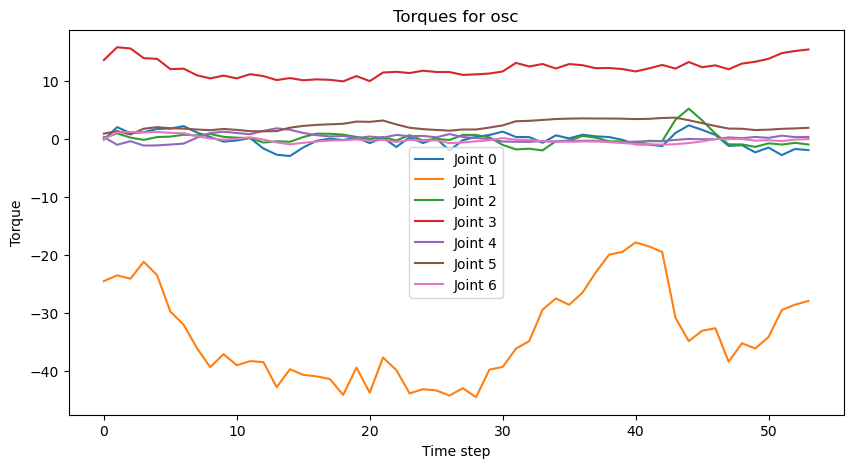

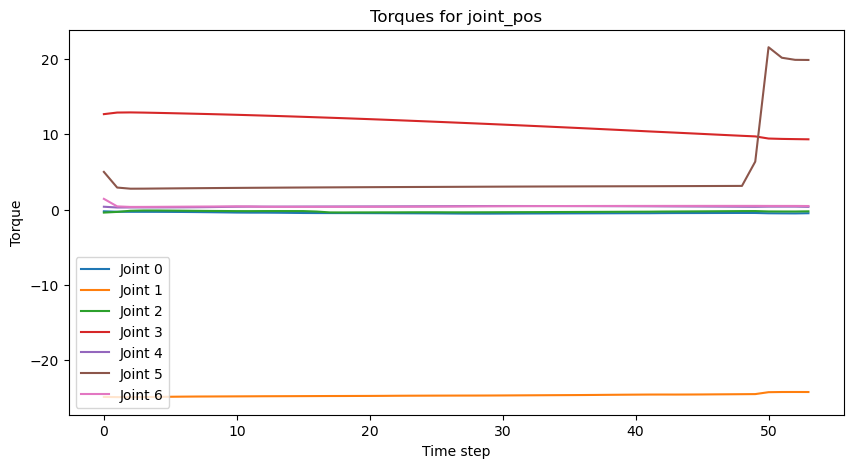

In [51]:
# plot torques
def plot_torques(torques_dict):
    for controller_name, torques in torques_dict.items():
        plt.figure(figsize=(10, 5))
        for i in range(len(torques[0])):
            plt.plot([t[i] for t in torques], label=f"Joint {i}")
        plt.title(f"Torques for {controller_name}")
        plt.xlabel("Time step")
        plt.ylabel("Torque")
        plt.legend()
        #plt.savefig(os.path.join(output_dir, f"{controller_name}_torques.png"))
    plt.show()

plot_torques(torques_dict)